<a href="https://colab.research.google.com/github/JoshM435/ACTCW2/blob/main/py/Q2_folder/ACT_CW2_Q2_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the Notebook Containing Problem 2 (Q2), in this notebook i will cover my approach to detecting airplanes within the Airbus Aircraft Detection Dataset from Kaggle. Overall this approach appears to be significantly more effective at detecting the airplanes within the images pf the Dataset. This is evident with the failings of the contouring method i made being limited by colour and size of planes, as well as having shadows and clouds completely interfere with the edge detection process.

In the majority of situations the Neural Network approach is significantly more effective when it comes to accurately detecting th airplanes. The only downside is the time taken to train the model, with training with 15 EPOCHS taking roughly 10 minutes to complete, however once this process is done the time taken to identify and locate the planes is relatively similar.

When approaching the Neural Network it is important to note I used a Faster C-NN Model, also known as a Region Based Convolutional Neural Network.

I chose this model for its ability to output bounding boxes, class labels, and confidence scores. Allowing for easy configuration with my chosen dataset, as these outputs are used within the dataset and can be used to train the model to more accurately look for planes.


Python Dependencies Needed to run this code:

In [ ]:
import kagglehub
import pandas as pd
import os
import tensorflow
import matplotlib.pyplot as plt
import ast
import torch
import torchvision.transforms as T
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import random
from torchvision.ops import box_iou
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_Weights

We first begin again with downloading the Airbus Aircraft Detection Dataset from kaggle, importing into the notebook through kagglehub.

Labeling pathways to both neccesary features; images and the annotation.csv file.

In [ ]:
# Download the dataset
path = kagglehub.dataset_download("airbusgeo/airbus-aircrafts-sample-dataset")
print("Path to dataset files:", path)

# Explore the annotations
annotations_path = os.path.join(path, "annotations.csv")
annotations = pd.read_csv(annotations_path)
print(annotations.head())

# Verify images
images_path = os.path.join(path, "images")
print("Number of images:", len(os.listdir(images_path)))


100%|██████████| 87.6M/87.6M [00:03<00:00, 26.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3
   id                                  image_id  \
0   1  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
1   2  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
2   3  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
3   4  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
4   5  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   

                                            geometry     class  
0  [(135, 522), (245, 522), (245, 600), (135, 600...  Airplane  
1  [(1025, 284), (1125, 284), (1125, 384), (1025,...  Airplane  
2  [(1058, 1503), (1130, 1503), (1130, 1568), (10...  Airplane  
3  [(813, 1518), (885, 1518), (885, 1604), (813, ...  Airplane  
4  [(594, 938), (657, 938), (657, 1012), (594, 10...  Airplane  
Number of images: 103


This function's purpose is to extract the polygon based data, as the bounding boxes within the dataset are stored as arrays of 5 tuples (x, y). Using this function we are able to determine the x_min, x_max, y_min, y_max of each bounding box and have correct bounding boxes to train with.

This is necessary for my model as it uses torch, which for some operations takes an input of x_min, x_max, y_min, y_max, so this extraction is required and done.

With a displayed annotations file with the newly acquired bbox column.

This allows the application of model training with the now parsed bounding boxes, so the model can learn from the dataset in identifying planes.

In [ ]:

# Function to parse the geometry field and extract a rectangular bounding box
def polygon_to_bbox(polygon_str):
    """
    Converts a polygon (as a string of tuples) to a bounding box (x_min, y_min, x_max, y_max).
    """
    # Parse the string to a list of tuples
    polygon = ast.literal_eval(polygon_str)
    # Extract x and y coordinates separately
    x_coords = [point[0] for point in polygon]
    y_coords = [point[1] for point in polygon]
    # Determine the bounding box
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    return x_min, y_min, x_max, y_max

# Apply the function to the annotations dataframe
annotations['bbox'] = annotations['geometry'].apply(polygon_to_bbox)

# Display the dataframe with the new bounding box column
annotations.head()


,id,image_id,geometry,class,bbox
0,1,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(135, 522), (245, 522), (245, 600), (135, 600...",Airplane,"(135, 522, 245, 600)"
1,2,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1025, 284), (1125, 284), (1125, 384), (1025,...",Airplane,"(1025, 284, 1125, 384)"
2,3,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1058, 1503), (1130, 1503), (1130, 1568), (10...",Airplane,"(1058, 1503, 1130, 1568)"
3,4,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(813, 1518), (885, 1518), (885, 1604), (813, ...",Airplane,"(813, 1518, 885, 1604)"
4,5,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(594, 938), (657, 938), (657, 1012), (594, 10...",Airplane,"(594, 938, 657, 1012)"


Within the next cell is the class definition for my Aircraft Dataset. Its purpose is to manage the loading and preparation of the lebeled data for training and evaluation. It folows to the PyTorch Dataset interface, which uses __len__ and __getitem__ methods.

__init__() is an initializer, it sets up the dataset with information:


1. annotations_df - A pandas DataFrame which holds image IDs, Bounding Boxes, and class labels.
2. images_dir - A directory from the imported dataset holding the corresponding image files.
3. transform - transformations to apply to the images: resizing, normalizing.

It maps the class names to numeric labels with self.class_to_label

It provides a reverse mapping for converting numeric labels back to class names.

__len__() - is used for Dataset Length. Returns the total number of unique images in the dataset. Its purpose is to help PyTorch determine the size of the dataset. This helps with batching in DataLoader.

__getitem__() - It is used to Retrieve an item, in this case it retrieves the data for a single image: pixel data for the image as a PyTorch Tensor, as well as retrieving the bounding box coordinates as a torch.FloatTensor, represented as (x_min, y_min, x_max, y_max), and the class labels for the objects in the image extracted as torch.IntTensor.

This function works through these following steps:



1.   Identify the image - finds image_id based off the index passed by the DataLoader, it then filters the annotations for this image using the DataFrame.
2.   Loads the Image - Reads the image file from images_dir, converts it to an RGB format with Pillow (Image.open)
3.   Prepare Targets - It extracts bounding boxes from the DataFrame, checking they are formatted as tensors, and converts class names to numeric labels using the mapping self.class_to_label.
4.   Transformations - If 'transform' is specified it applies them to the image (resizing or normalizing).

In turn it then returns the transformed image, and the corresponding dictionary containing the bounding boxes and labels.

All put together the class allows PyTorch's DataLoader to:


*   Efficiently retrieve and batch images with their corresponding bounding boxes and labels.
*   Pass these batches to the neural network for training/evaluation.

In [ ]:

# Define the custom PyTorch Dataset class
class AircraftDataset(Dataset):
    def __init__(self, annotations_df, images_dir, transform=None):
        """
        Args:
            annotations_df (pd.DataFrame): DataFrame containing image_id, bbox, and class.
            images_dir (str): Path to the directory containing images.
            transform (callable, optional): Optional transform to apply to images.
        """
        self.annotations_df = annotations_df
        self.images_dir = images_dir
        self.transform = transform
        # Map class names to numeric labels
        self.class_to_label = {cls: idx + 1 for idx, cls in enumerate(annotations_df['class'].unique())}
        self.label_to_class = {idx + 1: cls for idx, cls in enumerate(annotations_df['class'].unique())}

    def __len__(self):
        return len(self.annotations_df['image_id'].unique())

    def __getitem__(self, idx):
        # Get the image ID and filter annotations for this image
        image_id = self.annotations_df['image_id'].unique()[idx]
        image_path = os.path.join(self.images_dir, image_id)
        annotations = self.annotations_df[self.annotations_df['image_id'] == image_id]

        # Load the image
        image = Image.open(image_path).convert("RGB")

        # Extract bounding boxes and labels
        boxes = torch.tensor([list(bbox) for bbox in annotations['bbox']], dtype=torch.float32)
        labels = torch.tensor([self.class_to_label[cls] for cls in annotations['class']], dtype=torch.int64)

        # Create the target dictionary
        target = {"boxes": boxes, "labels": labels}

        # Apply transformations if specified
        if self.transform:
            image = self.transform(image)

        return image, target

# Define the image directory path
images_dir = os.path.join(path, 'images')

# Define simple transforms (resize and normalize images)
transform = T.Compose([
    T.ToTensor()
])

# Instantiate the dataset
dataset = AircraftDataset(annotations, images_dir, transform=transform)

# Display a sample for verification
sample_image, sample_target = dataset[0]
sample_image.shape, sample_target


(torch.Size([3, 2560, 2560]),
 {'boxes': tensor([[ 135.,  522.,  245.,  600.],
          [1025.,  284., 1125.,  384.],
          [1058., 1503., 1130., 1568.],
          [ 813., 1518.,  885., 1604.],
          [ 594.,  938.,  657., 1012.],
          [ 451.,  725.,  524.,  798.],
          [1543., 1437., 1614., 1497.],
          [1485., 1370., 1561., 1437.],
          [1968., 1624., 2053., 1687.],
          [1659., 1674., 1733., 1746.],
          [1865., 2091., 1951., 2165.],
          [2052., 1772., 2135., 1834.],
          [2146., 2031., 2225., 2102.],
          [1006., 2345., 1088., 2412.],
          [1931., 2163., 2009., 2247.],
          [1231., 1532., 1295., 1607.],
          [ 740., 1268.,  804., 1356.],
          [ 645., 1399.,  730., 1458.]]),
  'labels': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])})

The get_model function's purpose is to initialize and customize a Faster R-CNN model for object detection.

This function uses a Faster R-CNN model with a ResNet-50 backbone, and modifies its classification head to match the number of object classes in the kaggle dataset.

* Faster R-CNN model: with the backbone of ResNet-50, which is a NN used to extract features from the input image
* It consists of a Feature Pyramid Network (FPN) which enhances the backbone by combining features from different resolutions, making the model better at detecting the objects at various scales.

The next step is to customize the classifier, as the classifier for the imported model has a different classification for use with a different dataset, specifically the COCO dataset. So to make it function with the Kaggle dataset the classifier must be modified.

1. Retrieve the Features -
  * model.roi_heads.box_predictor.cls_score.in_features.
    * this retrieves the number of input features for the classification head. This is dependant on the backbone used (ResNet-50).
2. Replace the classifier head -
  * FastRCNNPredictor:
    * A new classifier is made with the use of torchvision.models.detection.faster_rcnn.FastRCNNPredictor.
    * it takes the number of input features and the number of classes (num_classes) as arguments.
    * this includes -
      * The number of object classes in the Kaggle dataset.
      * The backround class (class index 0).
3. Assign the New Classifier -
  * The box_predictor of the model's roi_heads is replaced with the custom classifier now relevant to the dataset being used.

The function then returns the now customized and initialized Faster R-CNN model.

In [ ]:
# Model Initialization
def get_model(num_classes):
    # Load a Faster R-CNN model
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT) #weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    # Update the classifier head for the number of classes (including background)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

The train_model() function is required to train the Faster R-CNN model. it controls the process of passing data through the model as well as computing losses, and updating the model's weights using backpropagation. This function also plots the loss as a graph against Epoch count.

Functionality of the train_model function:

1. Sets the model into training mode.
2. Iterates over the dataset in batches.
3. Computes loss for each batch (classification and bounding box regression losses).
4. updates model weights using an optimizer.
5. Tracks the training loss over epochs and plots it for analysis.

It takes inputs:

1. model: The faster C-NN model to be trained.
2. data_loader: A PyTorch DataLoader object that gives batches of images and their corresponding labels/annotations.
3. optimizer: The optimization algorithm used to update the model's weights.
4. num_epochs: the number of times the entire dataset is passed through the model.
5. device: specifies whether to run the training on a GPU('cuda') or CPU('cpu').

The batch loop:

* Load data:
  * Batches of images and their targets (bounding boxes and labels) are retrieved from the data loader.
  * The data is moved to specified device.
* Zero Gradients:
  * optimizer.zero_grad() ensures that gradients from the previous iteration are cleared before the next computation.
* Forward Pass:
  * The model processes the input images and computes the loss_dict.
  * loss_dict: A dictionary containing the individual loss components:
    * Classification Loss: How well the model can classify objects into their correct categories.
    * Regression Loss: How accurately the model predicts bounding box coordinates.
  * Aggregate Loss:
    * The total loss is computed as a sum of loss components.
  * Backward Pass:
    * losses.backward() computes the gradients of the loss with respect to the model's parameters.
  * Update Weights:
    * optimizer.step() updates the model's weights using the computed gradients.
  * Track Epoch loss:
    * Adds the batch loss to epoch_loss.

Workflow:

1. Inputs:
  * The model, optimizer, dataloader, number of epochs, and device.
2. Training Process:
  * For each epoch:
    * Iterate over batches of data.
    * Compute total loss for the batch.
    * Update the model's parameters to minimize the loss.
  * log and plot the loss curve.
3. Outputs:
  * A trained model with updated weights.
  * a loss history plot showing the training performance.

For the Data shown i ran an EPOCH count of 25, to increase the effectiveness of the model's functionality, versus my previous attempt of 15.

Epoch 1/25, Loss: 32.1004
Epoch 2/25, Loss: 18.0796
Epoch 3/25, Loss: 15.1243
Epoch 4/25, Loss: 12.5501
Epoch 5/25, Loss: 11.2921
Epoch 6/25, Loss: 10.5230
Epoch 7/25, Loss: 10.0072
Epoch 8/25, Loss: 9.3252
Epoch 9/25, Loss: 9.0632
Epoch 10/25, Loss: 8.7609
Epoch 11/25, Loss: 8.2493
Epoch 12/25, Loss: 8.1464
Epoch 13/25, Loss: 8.0448
Epoch 14/25, Loss: 7.3755
Epoch 15/25, Loss: 7.0507
Epoch 16/25, Loss: 6.8398
Epoch 17/25, Loss: 7.0697
Epoch 18/25, Loss: 7.5233
Epoch 19/25, Loss: 6.7248
Epoch 20/25, Loss: 6.6114
Epoch 21/25, Loss: 6.5336
Epoch 22/25, Loss: 6.5600
Epoch 23/25, Loss: 5.7794
Epoch 24/25, Loss: 5.7867
Epoch 25/25, Loss: 5.2960


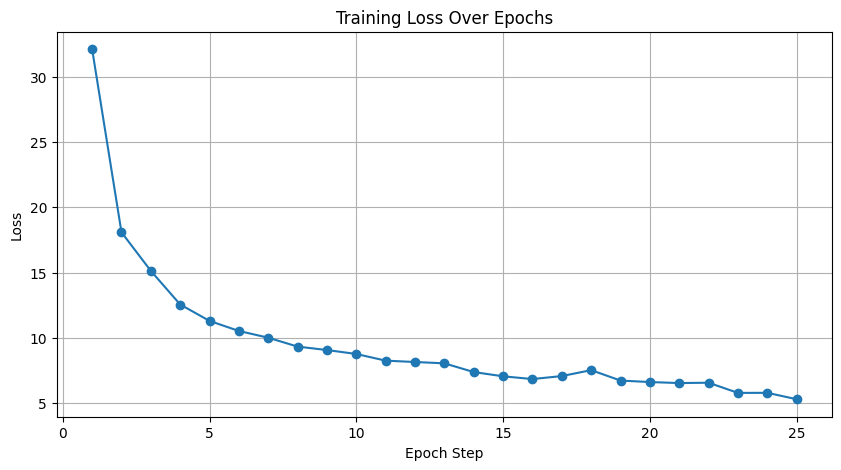

In [ ]:
# Training Loop
def train_model(model, data_loader, optimizer, num_epochs, device):
    model.to(device)
    model.train()

    loss_history = []
    for epoch in range(num_epochs):
        epoch_loss = 0
        for images, targets in data_loader:
            # Move data to the appropriate device
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass and loss computation
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            # Backward pass and optimisation
            losses.backward()
            optimizer.step()

            epoch_loss += losses.item()
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}")
    plt.figure(figsize=(10,5))
    plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
    plt.xlabel('Epoch Step')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid()
    plt.show()

# Data Preparation
# Assuming annotations_df is the preprocessed DataFrame and images_dir is the folder path
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

# Create Dataset and DataLoader
train_dataset = AircraftDataset(annotations, images_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Model, Optimiser, and Device Setup
num_classes = len(train_dataset.class_to_label) + 1  # +1 for background class
model = get_model(num_classes)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Train the Model
num_epochs = 25

train_model(model, train_loader, optimizer, num_epochs, device)


The test_model function below exists to test the trained Faster R-CNN model on a single random image from the dataset.

test_model:

1. Loads a random image from the dataset.
2. Uses the trained model to generate predictions through bounding boxes, class labels and confidence scores.
3. Filters predictions based on a confidence threshold.
4. Draws the predictions on the image.
5. Displays the annotated image for visual inspection.

Code Breakdown:

1. Select and process and image:
  * picks a random image, image.to(device) moves the image tensor to the same device as the model, unsqueeze(0) adds a batch dimension to the image tensor, as the model expects a batch of images for input.
2. perform inference:
  * torch.no_grad():
    * Disables gradient computation during inference to save memory and improve speed.
  * predictions:
    * A list of dictionaries, where each dictionary contains the predictions for an image in the dataset. Since a random image was processed there is only one dictionary in the list:
      * boxes: Bounding box coordinates.
      * labels: Predicted class labels.
      * scores: Confidence scores for each prediction.
3. Filter Predictions by Confidence Threshold:
  * Convert to Numpy Arrays
  * Filter Predictions:
    * Uses np.where(scores>= threshold) to retain only the predictions with confidence scores greater than the specified threshold (0.5 by default).
  * Filtered Results:
    * filtered_boxes: Coordinates of the bboxes that meet the threshold.
    * filtered_labels: Class labels for filtered boxes.
    * filtered_scores: Confidence scores for the filtered boxes.
4. Draw Predictions on the image:
  * convert image: converts the tensor back to a PIL image for visualisation.
  * drawing setup:
    * uses ImageDraw.Draw to annotate the image.
  * Draw Bounding Boxes:
    * Loops through the filtered predictions and draws a rectangle for each box (draw.rectangle).
  * Add text:
    * Displays the class label and confidence score.
5. Return Annotated Image.
  * Returns the annotated image which can be displayed or saved.

Workflow:

1. Inputs:
  * trained model, dataset, device, threshold to filter low-confidence predictions.
2. Inference Process:
  * take random image from  the dataset,
  pass it through the model to generate predictions, filter predictions on confidence score.
3. Output: the annotated image, showing bounding boxes and class labels with confidence scores.

It is useful for qualitative Evaluation and visual debugging.

In [ ]:
# Test Function
def test_model(model, dataset, device, threshold=0.5):
    model.to(device)
    model.eval()

    # Get a sample image and its target
    image, _ = dataset[random.randint(0,102)]  # Modify index to test different images
    image_tensor = image.to(device).unsqueeze(0)  # Add batch dimension

    # Make predictions
    with torch.no_grad():
        predictions = model(image_tensor)

    # Filter predictions by score threshold
    scores = predictions[0]['scores'].cpu().numpy()
    boxes = predictions[0]['boxes'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()

    filtered_indices = np.where(scores >= threshold)[0]
    filtered_boxes = boxes[filtered_indices]
    filtered_labels = labels[filtered_indices]
    filtered_scores = scores[filtered_indices]

    # Draw predictions on the image
    image = F.to_pil_image(image.cpu())
    draw = ImageDraw.Draw(image)

    Font_Size= 40
    font= ImageFont.load_default(Font_Size)


    for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
        draw.rectangle(box.tolist(), outline="red", width=3)
        text = f"{dataset.label_to_class[label]}: {score:.2f}"
        draw.text((box[0]-40, box[1] - Font_Size), text, fill="red", font=font )

    return image

The predict_on_unseen_images function is used to apply the now trained model to a dataset which doesn't have ground truth annotations, it performs the predictions, filters the results, and save annotated images to a specified output directory.

It follows a very similar purpose to the test_model function, but it is used to est the extras/ images within the kaggle dataset as they do not have a annotations.csv file. and so must have an adapted function to test them.

Its main difference is in making a new directory, to store the annotated predictions on the extra images.

Workflow:

1. Inputs: trained Faster R-CNN model.
2. Inference:
  * Runs the  model on each image in the dataset.
  * filters low-confidence predictions.
  * Annotates the image with bounding boxes, class labels and scores.
3. Outputs: Annotated images are saved to the specified directory.



In [ ]:
def predict_on_unseen_images(model, dataset, device, output_dir, threshold=0.5):
    model.to(device)
    model.eval()
    os.makedirs(output_dir, exist_ok=True)

    for image, image_name in dataset:
        image_tensor = image.to(device).unsqueeze(0)  # Add batch dimension

        # Make predictions
        with torch.no_grad():
            predictions = model(image_tensor)

        # Filter predictions by score threshold
        scores = predictions[0]['scores'].cpu().numpy()
        boxes = predictions[0]['boxes'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()

        filtered_indices = np.where(scores >= threshold)[0]
        filtered_boxes = boxes[filtered_indices]
        filtered_labels = labels[filtered_indices]
        filtered_scores = scores[filtered_indices]

        # Draw predictions on the image
        image = F.to_pil_image(image.cpu())
        draw = ImageDraw.Draw(image)

        # Load a larger font
        font_size = 40

        font = ImageFont.load_default(font_size)


        for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
            draw.rectangle(box.tolist(), outline="red", width=3)
            text = f"Label {label}: {score:.2f}"
            text_position = (box[0], box[1] - font_size if box[1] - font_size > 0 else box[1] + 5)
            draw.text(text_position, text, fill="red", font=font)

        # Save the annotated image
        output_path = os.path.join(output_dir, image_name)
        image.save(output_path)
        print(f"Processed and saved: {output_path}")

The class UnlabelledImageDataset() is necessary to make a dataset which the predict_on_unseen_images() function can work with.

Its needed to test the trained model on unseen data, where it can generate predictions for the set of unseen images and saving the annotated results.

It functions very similarly to the AircraftDataset() class, where in this case the purpose is to:
 * Load images from a directory without requiring labels or bounding boxes.
 * Provide images in a format compatible with PyTorch models.

In [ ]:
class UnlabelledImageDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        """
        Args:
            images_dir (str): Path to the directory containing images.
            transform (callable, optional): Optional transform to apply to images.
        """
        self.images_dir = images_dir
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.image_files[idx]

In the Cell below shows an image taken from the training dataset with the models predicted objects, with relevant labels and confidence rates.

Where the two classes are AirPlane and Truncated AirPlane.

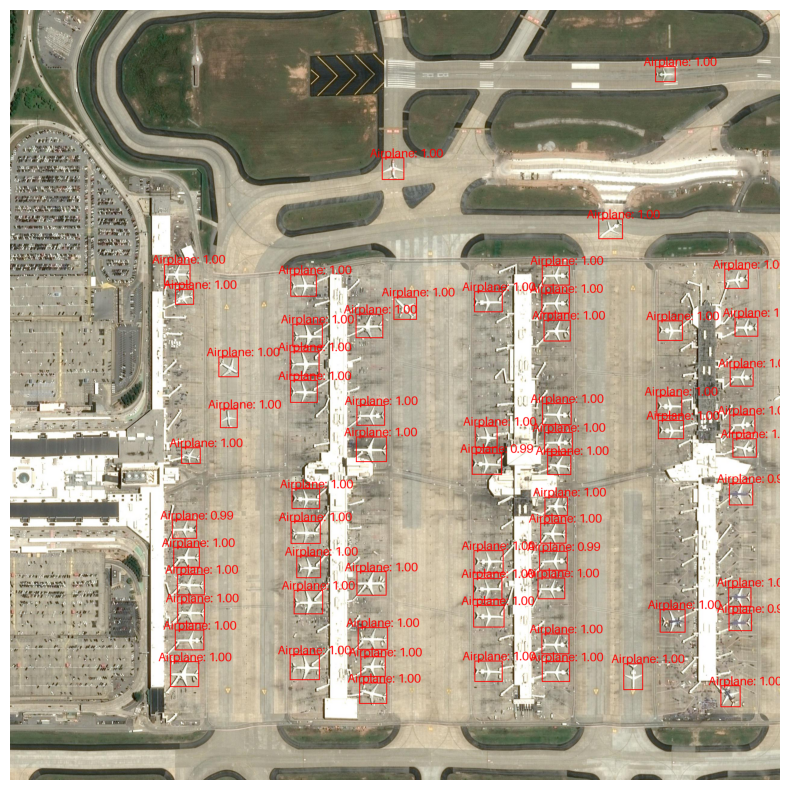

In [ ]:
import matplotlib.pyplot as plt


output_image = test_model(model, train_dataset, device)
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.axis('off')
plt.show()

The cell below details the allocation of the extras directory and the extras directory, and also the allocation of the output directory.

Whilst also executing predict_on_unseen_images() to make the images to display the predicted annotations on the extras images.

In [ ]:
extras_dir = os.path.join(os.path.dirname(images_dir), 'extras')
extras_dataset = UnlabelledImageDataset(extras_dir, transform=transform)

output_dir = os.path.join(os.path.dirname(images_dir), 'predictions')
predict_on_unseen_images(model, extras_dataset, device, output_dir)

Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/65825eef-f8a1-41b3-ac87-4a0a7d482a0e.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/08a8132a-a6c7-4cab-adee-7e2976fd2822.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/22bc9d20-02c4-4554-8fed-2c127d54b5ed.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/defbf838-828b-4427-9bb7-9af33563ea9c.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/55aa185a-01c8-4668-ae87-1f1d67d15a08.jpg
Processed and saved: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/predictions/022f91f0-1434-401f-a11b-e315b7068100.jpg


Debugging to check the pathway for the newly created predictions for the extras images.

In [ ]:
files = os.listdir(path)
print("Files in dataset:", files)
extras_predictions = os.listdir(output_dir)
print("Files in predictions:", extras_predictions)


Files in dataset: ['extras', 'images', 'README.md', 'LICENSE.txt', 'predictions', 'annotations.csv']
Files in predictions: ['65825eef-f8a1-41b3-ac87-4a0a7d482a0e.jpg', '08a8132a-a6c7-4cab-adee-7e2976fd2822.jpg', '22bc9d20-02c4-4554-8fed-2c127d54b5ed.jpg', 'defbf838-828b-4427-9bb7-9af33563ea9c.jpg', '55aa185a-01c8-4668-ae87-1f1d67d15a08.jpg', '022f91f0-1434-401f-a11b-e315b7068100.jpg']


In the cell below shows the code to display the generated annotations based on the models training on the kaggle dataset, this is shown through an unseen image having its predicted bounding boxes plotted, alongside the labels and confidence scores for the predictions.

Where:

Label 1 is a predicted airplane.

Label 2 is a predicted truncated airplane.

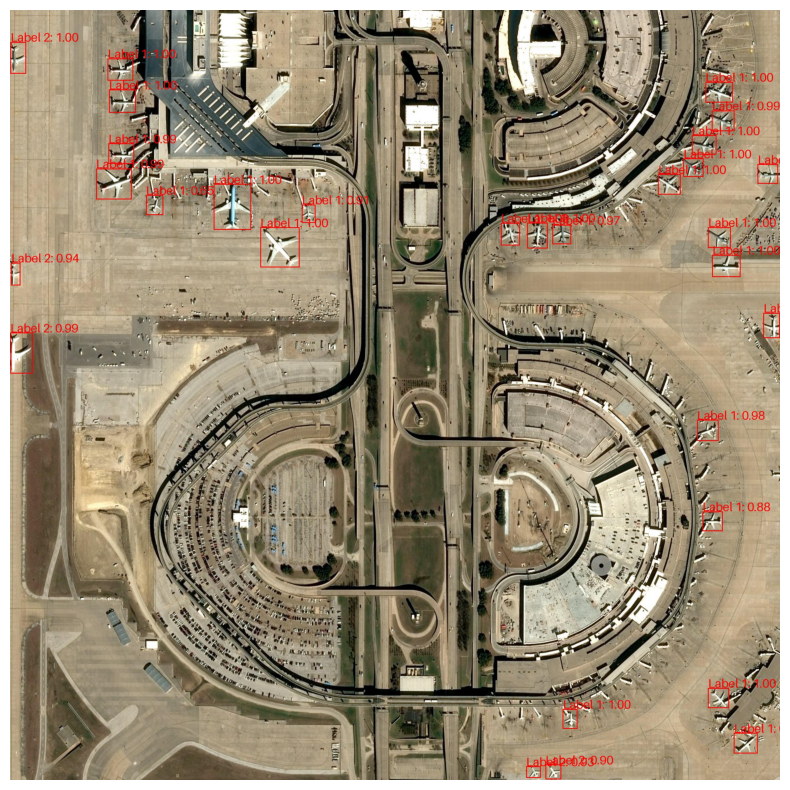

In [ ]:
extras_P = os.path.join(output_dir, extras_predictions[random.randint(0,5)])
extras_Random = Image.open(extras_P).convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(extras_Random)
plt.axis('off')
plt.show()

The cell below shows the function evaluate_model() which is used to evaluate the model that has been trained, and compare its generated predicted bounding boxes to the ground truth boxes.

the function's purpose:

1. Compares the model's predictions against the ground truth annotations.
2. Computes metrics:
  * Precision: The proportion of correctly predicted objects out of all predictions.
  * Recall: The proportion of correctly predicted objects out of all ground truth objects.

The code Breakdown:
  1. Initialize metrics
    * total_true_positives: Tracks the number of correctly predicted bounding boxes.
    * total_predictions: Tracks the total number of bounding boxes predicted by the model.
    * total_ground_truths: Tracks the total number of ground truth bounding boxes.
  
  They are used to calculate precision and recall.
  2. Loop Through the Test Dataset
    * Iterates over the test dataset using the DataLoader.
    * images: A batch of test images.
    * targets: Ground truth annotations for the images.
    * torch.no_grad(): Ensures no gradients are calcualated, saving memory and improving inference speed.
    * predictions: A list of dictionaries, where each dictionary:
      * boxes: Predicted bounding boxes.
      * labels: Predicted class labels.
      * scores: Confidence scores for each prediction.
  3. Process Each Image in the Batch:
    * pred_boxes: Bounding boxes predicted by the model for image i.
    * gt_boxes: Ground truth bounding boxes for image i.
    * pred_scores: Confidence scores for each predicted box.
    * gt_labels: Ground truth labels for the image.
  
  These predictions and ground truth data are then compared to calculate metrics.
  4. Filter Predictions by Confidence Threshold:
    * Filters out predictions with confidence scores below the threshold.
    * Retains only high-confidence predictions for evaluation.
  5. Compute IoU and True Positives:
    * box_iou(pred_boxes, gt_boxes):
      * Computes the Intersection-over-Union (IoU) between predicted and ground truth bounding boxes.
      *IoU measures the overlap between two boxes, with a higher value indicating a better match.
    * ious.max(dim=1)[0] > iou_threshold:
      * For each predicted box, checks if its highest IoU with a ground truth box exceeds the threshold (0.5 by default).
    * true_positives:
      * Counts the number of predictions that qualify as true positives based on the IoU threshold.
  6. Update Metrics:
    * total_ground_truths: Increments by the number of ground truth boxes in the image.
    * total_predictions: Increments by the number of predicted boxes for the image.
  7. Compute Metrics:
    * precision:
      * Measures how many of the predicted boxes were correct.
      * Formula: Precision = True positives/Total Prediction.
    * Recall:
      * Measures how many ground truth boxes were correctly detected.
      * Formula: Recall = True Positives/Total Ground Truths.
  8. Display Metrics:
    * Logs the precision and recall values
    * Returns the metrics for further use or analysis.


In [ ]:

def evaluate_model(model, test_loader, device, iou_threshold=0.5):
    model.to(device)
    model.eval()

    total_true_positives = 0
    total_predictions = 0
    total_ground_truths = 0

    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        with torch.no_grad():
            predictions = model(images)

        for i, prediction in enumerate(predictions):
            pred_boxes = prediction['boxes'].cpu()
            pred_labels = prediction['labels'].cpu()
            pred_scores = prediction['scores'].cpu()

            gt_boxes = targets[i]['boxes']
            gt_labels = targets[i]['labels']

            # Filter predictions by confidence threshold
            filtered_indices = pred_scores > 0.5
            pred_boxes = pred_boxes[filtered_indices]
            pred_labels = pred_labels[filtered_indices]

            # Count total ground truths and predictions
            total_ground_truths += len(gt_boxes)
            total_predictions += len(pred_boxes)

            # Compute IoU and count true positives
            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                ious = box_iou(pred_boxes, gt_boxes)
                true_positives = (ious.max(dim=1)[0] > iou_threshold).sum().item()
                total_true_positives += true_positives

    # Compute metrics
    precision = total_true_positives / total_predictions if total_predictions > 0 else 0
    recall = total_true_positives / total_ground_truths if total_ground_truths > 0 else 0

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    return precision, recall

evaluate_model(model, train_loader, device)

Precision: 0.9856
Recall: 0.9425


(0.9856488549618321, 0.9424817518248175)

Overall, this Neural Network has proven to be a much more effective method of identifying Airplanes within the Airbus Dataset, and with a recall accuracy of ~0.942 and a precision of ~0.985 this NN has been shown to relatively effective, at least marginally in comparison to the edge-detection/contour-analysis method.

The reasoning behind choosing the Faster R-CNN is because it aligns with the nature of the Airbus Dataset, as Faster R-CNN is designed for detecting multiple objects in an image, including handling their locations (bounding boxes) and classes.

Another impactful feature which helped me choose this method is that F R-CNN uses a Region Proposal Network (RPN) and Feature Pyramid Network (FPN), which are excellent for detecting objects at different scales and resolutions.

Two-step Detecion Pipeline:

1. RPN:
  * The RPN efficiently generates regions of interest (RoIs) where are objects are likely to exist.
  * Which aligns with the dataset, as it is useful in minimizing false positives in cluttered scenes, this is useful for images with multiple aircraft and potential false positives such as clouds or runways.

2. For the Second Stage:
  * F R-CNN classifies the object and refines the bounding box coordinates for accuracy purposes.
  * This dual-stage approach intends to improve accuracy for localization and classification.

Backbone for Feature Extraction:
  * F R-CNN uses a backbone in ResNet-50, which extracts features like edges, textures, and object shapes from images.
  * This applies to the dataset through:
    * being able to efficiently handle the variety of appearances (shape, colour, size) that exist for aircraft.

Handling for Overlapping Objects:
  * Aircraft can potentially overlap or be positioned close together, where F C-NN is capable of handling overlapping objects by using IoU based region proposals.
  * Whilst also using Non-Maximum Suppresion (NMS) to try and filter redundant detections.

F R-CNN is a flexible model:
  * It supports multi-class detection, which coincides with the datasets class count of 2: Airplane, Truncated Airplane.

F R-CNN is an easy to interpret model, with the ability to visualise all necessary predictions, alongside their corresponding values, and analyse it visually plotted onto the dataset, with the ability to measure performance quantitatively through Precision and Recall values.

Which all-together shows this iteration of a Neural Network is a good alternative to traditional methods of analysing this dataset, with marginally increased accuracy and precision when predicting the locations of planes.

The code in this Notebook has been adapted from Kaggle and Chatgpt.